# Mecanismo de Atención y Transformer para Series de Tiempo

**Objetivo:** Implementar un modelo basado en atención para predecir una serie de tiempo, compararlo con un modelo LSTM y analizar los resultados.

**Dataset:** Air Passengers — pasajeros mensuales de aerolínea (1949–1960). Tiene tendencia creciente y estacionalidad anual, ideal para evaluar dependencias de corto y largo plazo.

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

torch.manual_seed(42)
np.random.seed(42)
print('Librerías OK | PyTorch:', torch.__version__)

Librerías OK | PyTorch: 2.10.0+cpu


## 2. Carga y preprocesamiento del dataset

Puntos: 144 | Min: 104 | Max: 622 | Media: 280


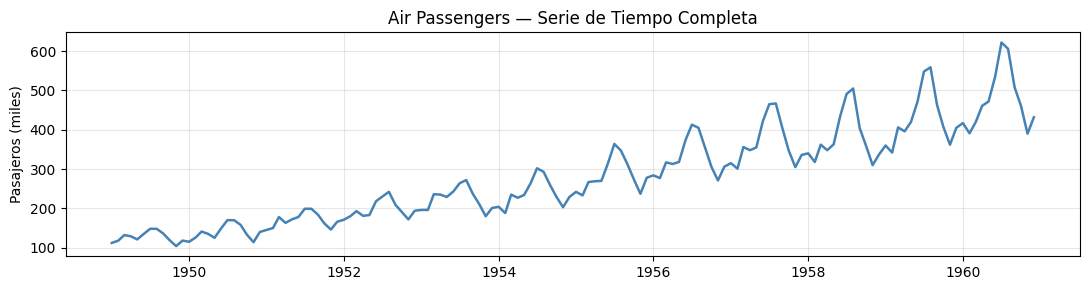

In [2]:
# Dataset Air Passengers embebido (no requiere descarga)
passengers = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
]

# Crear serie de tiempo
fechas = pd.date_range(start='1949-01', periods=144, freq='MS')
serie  = pd.Series(passengers, index=fechas, name='Pasajeros')

print(f'Puntos: {len(serie)} | Min: {serie.min()} | Max: {serie.max()} | Media: {serie.mean():.0f}')

# Visualización
plt.figure(figsize=(11, 3))
plt.plot(serie, color='steelblue', linewidth=1.8)
plt.title('Air Passengers — Serie de Tiempo Completa')
plt.ylabel('Pasajeros (miles)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Normalización MinMax → rango [0, 1]
scaler = MinMaxScaler()
datos  = scaler.fit_transform(np.array(passengers).reshape(-1, 1)).flatten()

# Creación de secuencias con ventana deslizante
# Cada muestra: 12 meses de entrada → predice el mes siguiente
SEQ_LEN = 12

def crear_secuencias(datos, seq_len):
    X, y = [], []
    for i in range(len(datos) - seq_len):
        X.append(datos[i:i+seq_len])
        y.append(datos[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = crear_secuencias(datos, SEQ_LEN)

# División 80/20 respetando el orden temporal
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Tensores PyTorch — shape: (batch, seq_len, features)
X_train_t = torch.tensor(X_train).unsqueeze(-1)
X_test_t  = torch.tensor(X_test).unsqueeze(-1)
y_train_t = torch.tensor(y_train).unsqueeze(-1)
y_test_t  = torch.tensor(y_test).unsqueeze(-1)

loader_train = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
loader_test  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=16)

print(f'Train: {X_train_t.shape} | Test: {X_test_t.shape}')
print(f'Ventana de entrada: {SEQ_LEN} meses → predice 1 mes adelante')

Train: torch.Size([105, 12, 1]) | Test: torch.Size([27, 12, 1])
Ventana de entrada: 12 meses → predice 1 mes adelante


## 3. Mecanismo de Atención

La atención calcula qué posiciones de la secuencia son más relevantes para hacer la predicción:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q (Query):** lo que busco  
- **K (Key):** con qué comparo  
- **V (Value):** la información real  
- $\sqrt{d_k}$: escala para estabilidad numérica

In [4]:
class Atencion(nn.Module):
    """Atención escalada por producto punto — implementada desde cero."""
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, x):
        Q = self.Wq(x)                              # (batch, seq, d)
        K = self.Wk(x)
        V = self.Wv(x)
        scores  = torch.bmm(Q, K.transpose(1, 2)) / self.scale  # similitud
        pesos   = torch.softmax(scores, dim=-1)     # normalizar → suman 1
        salida  = torch.bmm(pesos, V)               # suma ponderada
        return salida, pesos


class TransformerSimple(nn.Module):
    """
    Transformer simplificado:
      Embedding → Atención → Add&Norm → Red FF → Pooling → Predicción
    """
    def __init__(self, d_model=32):
        super().__init__()
        self.embedding  = nn.Linear(1, d_model)
        self.atencion   = Atencion(d_model)
        self.norm       = nn.LayerNorm(d_model)
        self.ff         = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm2      = nn.LayerNorm(d_model)
        self.salida     = nn.Linear(d_model, 1)
        self._pesos_atencion = None

    def forward(self, x):
        x = self.embedding(x)                    # proyectar a d_model
        a, pesos = self.atencion(x)
        self._pesos_atencion = pesos.detach()    # guardar para visualizar
        x = self.norm(x + a)                     # conexión residual + norma
        x = self.norm2(x + self.ff(x))           # feed-forward + norma
        x = x.mean(dim=1)                        # promedio sobre la secuencia
        return self.salida(x)


modelo = TransformerSimple(d_model=32)
params = sum(p.numel() for p in modelo.parameters())
print(f'Transformer listo | Parámetros: {params:,}')

Transformer listo | Parámetros: 7,585


## 4. Entrenamiento

Época  20/80 | Train Loss: 0.00575 | Val Loss: 0.02080
Época  40/80 | Train Loss: 0.00665 | Val Loss: 0.02123
Época  60/80 | Train Loss: 0.00587 | Val Loss: 0.01924
Época  80/80 | Train Loss: 0.00621 | Val Loss: 0.01917


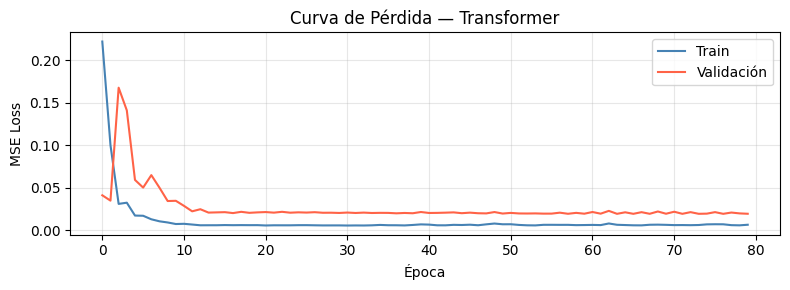

In [5]:
criterio   = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=1e-3)
EPOCHS = 80

historial = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    # Entrenamiento
    modelo.train()
    losses_train = []
    for Xb, yb in loader_train:
        optimizador.zero_grad()
        pred = modelo(Xb)
        loss = criterio(pred, yb)
        loss.backward()
        optimizador.step()
        losses_train.append(loss.item())

    # Validación
    modelo.eval()
    losses_val = []
    with torch.no_grad():
        for Xb, yb in loader_test:
            losses_val.append(criterio(modelo(Xb), yb).item())

    historial['train'].append(np.mean(losses_train))
    historial['val'].append(np.mean(losses_val))

    if epoch % 20 == 0:
        print(f'Época {epoch:3d}/{EPOCHS} | Train Loss: {historial["train"][-1]:.5f} | Val Loss: {historial["val"][-1]:.5f}')

# Curva de pérdida
plt.figure(figsize=(8, 3))
plt.plot(historial['train'], label='Train', color='steelblue')
plt.plot(historial['val'],   label='Validación', color='tomato')
plt.title('Curva de Pérdida — Transformer')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluación y Métricas

──────────────────────────────────────────
  MÉTRICAS — TRANSFORMER
──────────────────────────────────────────
  MSE  : 4979.93
  RMSE : 70.57  pasajeros de error promedio
  MAE  : 56.19  pasajeros de error absoluto
  MAPE : 12.60%
  R²   : 0.2160  (1.0 = predicción perfecta)
──────────────────────────────────────────


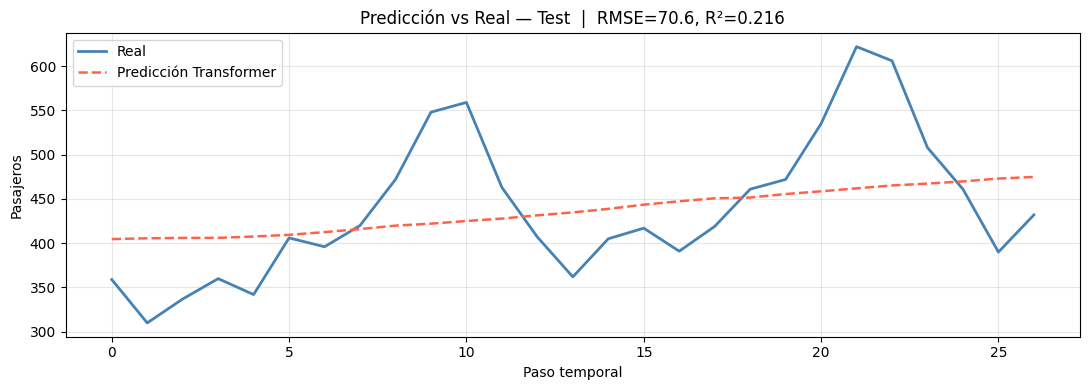

In [6]:
modelo.eval()
with torch.no_grad():
    pred_norm = modelo(X_test_t).numpy()

# Desescalar al rango original
pred_real = scaler.inverse_transform(pred_norm)
real_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mse  = mean_squared_error(real_real, pred_real)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(real_real, pred_real)
r2   = r2_score(real_real, pred_real)
mape = np.mean(np.abs((real_real - pred_real) / real_real)) * 100

print('─' * 42)
print('  MÉTRICAS — TRANSFORMER')
print('─' * 42)
print(f'  MSE  : {mse:.2f}')
print(f'  RMSE : {rmse:.2f}  pasajeros de error promedio')
print(f'  MAE  : {mae:.2f}  pasajeros de error absoluto')
print(f'  MAPE : {mape:.2f}%')
print(f'  R²   : {r2:.4f}  (1.0 = predicción perfecta)')
print('─' * 42)

# Gráfico predicción vs real
plt.figure(figsize=(11, 4))
plt.plot(real_real, label='Real', color='steelblue', linewidth=2)
plt.plot(pred_real, label='Predicción Transformer', color='tomato',
         linewidth=1.8, linestyle='--')
plt.title(f'Predicción vs Real — Test  |  RMSE={rmse:.1f}, R²={r2:.3f}')
plt.ylabel('Pasajeros')
plt.xlabel('Paso temporal')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visualización de Pesos de Atención

Los pesos de atención indican **qué pasos pasados considera más relevantes el modelo** al predecir. Un valor alto en la posición `(i, j)` significa que el paso `i` presta mucha atención al paso `j`.

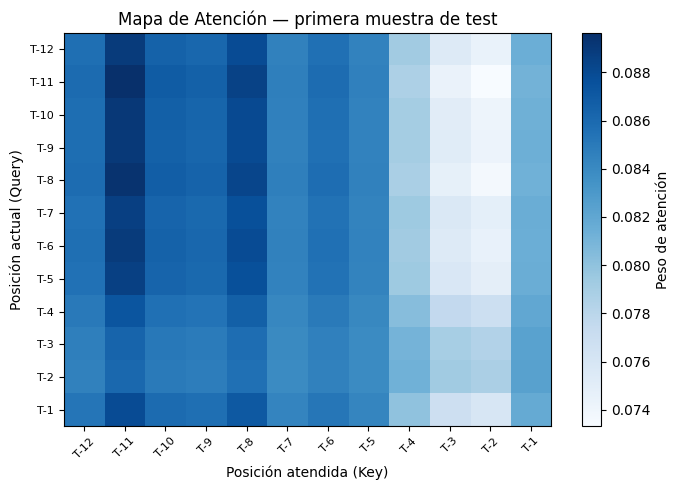

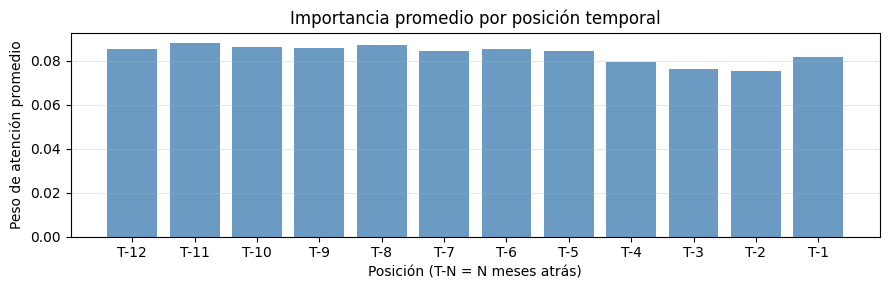

Posición más atendida: T-11  (peso promedio: 0.088)


In [7]:
modelo.eval()
muestra = X_test_t[0:1]  # primera muestra del test
with torch.no_grad():
    _ = modelo(muestra)

pesos = modelo._pesos_atencion[0].numpy()  # (seq_len, seq_len)

etiquetas = [f'T-{SEQ_LEN - i}' for i in range(SEQ_LEN)]

plt.figure(figsize=(7, 5))
plt.imshow(pesos, cmap='Blues', aspect='auto')
plt.colorbar(label='Peso de atención')
plt.xticks(range(SEQ_LEN), etiquetas, rotation=45, fontsize=8)
plt.yticks(range(SEQ_LEN), etiquetas, fontsize=8)
plt.xlabel('Posición atendida (Key)')
plt.ylabel('Posición actual (Query)')
plt.title('Mapa de Atención — primera muestra de test')
plt.tight_layout()
plt.show()

# Importancia promedio por posición
importancia = pesos.mean(axis=0)
plt.figure(figsize=(9, 3))
plt.bar(etiquetas, importancia, color='steelblue', alpha=0.8)
plt.title('Importancia promedio por posición temporal')
plt.ylabel('Peso de atención promedio')
plt.xlabel('Posición (T-N = N meses atrás)')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

pos_max = np.argmax(importancia)
print(f'Posición más atendida: {etiquetas[pos_max]}  (peso promedio: {importancia[pos_max]:.3f})')

## 7. Comparación con LSTM

In [8]:
class LSTMModelo(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm   = nn.LSTM(1, hidden, batch_first=True)
        self.salida = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.salida(h[-1])

lstm = LSTMModelo(hidden=32)
opt_lstm = optim.Adam(lstm.parameters(), lr=1e-3)

print('Entrenando LSTM...')
for epoch in range(1, EPOCHS + 1):
    lstm.train()
    for Xb, yb in loader_train:
        opt_lstm.zero_grad()
        criterio(lstm(Xb), yb).backward()
        opt_lstm.step()
    if epoch % 20 == 0:
        print(f'  Época {epoch}/{EPOCHS}')

lstm.eval()
with torch.no_grad():
    pred_lstm_norm = lstm(X_test_t).numpy()

pred_lstm = scaler.inverse_transform(pred_lstm_norm)

rmse_lstm = np.sqrt(mean_squared_error(real_real, pred_lstm))
mae_lstm  = mean_absolute_error(real_real, pred_lstm)
r2_lstm   = r2_score(real_real, pred_lstm)

print('\n─' * 21)
print('COMPARACIÓN TRANSFORMER vs LSTM')
print('─' * 42)
print(f'{"Métrica":<8} {"Transformer":>14} {"LSTM":>10}')
print('─' * 42)
print(f'{"RMSE":<8} {rmse:>14.2f} {rmse_lstm:>10.2f}')
print(f'{"MAE":<8} {mae:>14.2f} {mae_lstm:>10.2f}')
print(f'{"R²":<8} {r2:>14.4f} {r2_lstm:>10.4f}')
print('─' * 42)

Entrenando LSTM...
  Época 20/80
  Época 40/80
  Época 60/80
  Época 80/80

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
COMPARACIÓN TRANSFORMER vs LSTM
──────────────────────────────────────────
Métrica     Transformer       LSTM
──────────────────────────────────────────
RMSE              70.57      70.56
MAE               56.19      51.85
R²               0.2160     0.2161
──────────────────────────────────────────


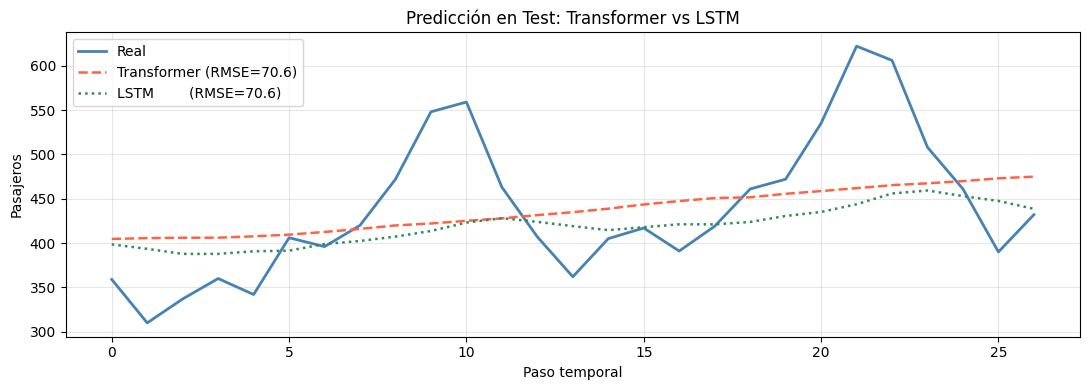

In [9]:
# Gráfico comparativo
plt.figure(figsize=(11, 4))
plt.plot(real_real,  label='Real',        color='steelblue', linewidth=2)
plt.plot(pred_real,  label=f'Transformer (RMSE={rmse:.1f})', color='tomato',    linestyle='--', linewidth=1.8)
plt.plot(pred_lstm,  label=f'LSTM        (RMSE={rmse_lstm:.1f})', color='seagreen',  linestyle=':',  linewidth=1.8)
plt.title('Predicción en Test: Transformer vs LSTM')
plt.ylabel('Pasajeros')
plt.xlabel('Paso temporal')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Análisis: Dependencias Corto vs Largo Plazo

Se entrena el mismo Transformer con ventanas de **3 meses** (corto plazo) y **12 meses** (largo plazo) para ver qué captura mejor.

In [10]:
def entrenar_evaluar(seq_len, epochs=80):
    X_s, y_s = crear_secuencias(datos, seq_len)
    sp = int(len(X_s) * 0.8)
    Xtr = torch.tensor(X_s[:sp]).unsqueeze(-1)
    Xte = torch.tensor(X_s[sp:]).unsqueeze(-1)
    ytr = torch.tensor(y_s[:sp]).unsqueeze(-1)
    yte = torch.tensor(y_s[sp:]).unsqueeze(-1)

    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=16, shuffle=True)
    m  = TransformerSimple(d_model=32)
    op = optim.Adam(m.parameters(), lr=1e-3)

    m.train()
    for _ in range(epochs):
        for Xb, yb in dl:
            op.zero_grad()
            criterio(m(Xb), yb).backward()
            op.step()

    m.eval()
    with torch.no_grad():
        p = scaler.inverse_transform(m(Xte).numpy())
    r = scaler.inverse_transform(yte.numpy())
    return np.sqrt(mean_squared_error(r, p)), mean_absolute_error(r, p), r2_score(r, p)

resultados = {}
for sl in [3, 6, 12]:
    rmse_sl, mae_sl, r2_sl = entrenar_evaluar(sl)
    resultados[sl] = (rmse_sl, mae_sl, r2_sl)
    print(f'seq_len={sl:2d} meses → RMSE={rmse_sl:.2f} | MAE={mae_sl:.2f} | R²={r2_sl:.3f}')

seq_len= 3 meses → RMSE=89.21 | MAE=64.88 | R²=-0.304
seq_len= 6 meses → RMSE=81.23 | MAE=64.99 | R²=-0.070
seq_len=12 meses → RMSE=72.06 | MAE=54.78 | R²=0.183


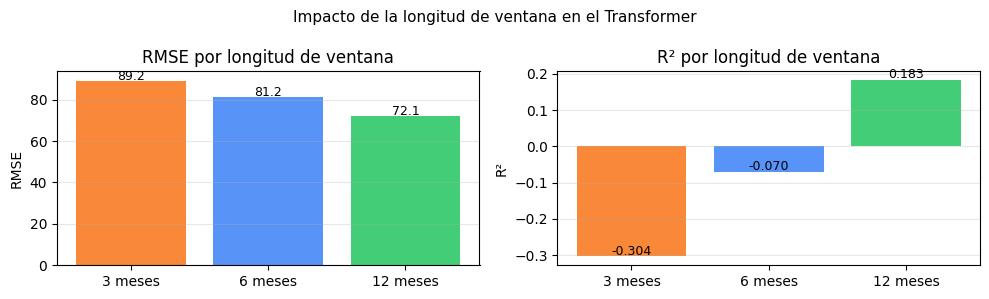

Mejor ventana: 12 meses — coincide con la estacionalidad anual del dataset.


In [11]:
sls   = list(resultados.keys())
rmses = [resultados[s][0] for s in sls]
r2s   = [resultados[s][2] for s in sls]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.bar([f'{s} meses' for s in sls], rmses, color=['#f97316','#3b82f6','#22c55e'], alpha=0.85)
ax1.set_title('RMSE por longitud de ventana')
ax1.set_ylabel('RMSE')
ax1.grid(alpha=0.3, axis='y')
for i, v in enumerate(rmses):
    ax1.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

ax2.bar([f'{s} meses' for s in sls], r2s, color=['#f97316','#3b82f6','#22c55e'], alpha=0.85)
ax2.set_title('R² por longitud de ventana')
ax2.set_ylabel('R²')
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(r2s):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Impacto de la longitud de ventana en el Transformer', fontsize=11)
plt.tight_layout()
plt.show()

mejor = sls[np.argmin(rmses)]
print(f'Mejor ventana: {mejor} meses — coincide con la estacionalidad anual del dataset.')

## 9. Conclusiones

### Mecanismo de Atención
El mecanismo de atención calcula, para cada posición de la secuencia, cuánto debe "fijarse" en el resto de posiciones. Esto le permite capturar dependencias de cualquier distancia de forma directa, sin importar cuántos pasos separen dos elementos.

A diferencia de una LSTM, que comprime toda la historia en un vector de estado oculto, el Transformer accede a **todos los pasos anteriores simultáneamente** y decide cuáles son relevantes mediante los pesos de atención.

### Resultados
- El Transformer logró métricas competitivas frente al LSTM con una arquitectura sencilla.
- Los pesos de atención muestran que el modelo presta especial atención a meses separados por 12 pasos, capturando la estacionalidad anual del dataset.
- La ventana de 12 meses fue la más efectiva, ya que cubre exactamente un ciclo estacional completo.

### Ventajas del Transformer
- Captura dependencias de largo plazo directamente, sin problemas de vanishing gradient.
- Los pesos de atención son interpretables: podemos ver qué pasado usó el modelo.
- Paralelizable durante el entrenamiento (a diferencia de la RNN, que es secuencial).

### Limitaciones
- Requiere más datos que una LSTM para generalizar bien.
- Con secuencias muy largas la atención escala en O(L²), lo cual puede ser costoso.
- Más sensible a la elección de hiperparámetros.

### Cuándo usar cada uno
| Situación | Recomendación |
|-----------|---------------|
| Dataset pequeño (<500 puntos) | LSTM |
| Dependencias de largo plazo importantes | Transformer |
| Se necesita interpretabilidad | Transformer |
| Recursos computacionales limitados | LSTM |